# Basic classification: Classify images of clothing

In [3]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


In [4]:
# Importing the mnist dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

# Splitting the dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [5]:
# Loading the dataset returns four NumPy arrays:

# The train_images and train_labels arrays are the training set—the data the model uses to learn.
# The model is tested against the test set, the test_images, and test_labels arrays.
# The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The labels are an array of integers, ranging from 0 to 9. These correspond to the class of clothing the image represents:

# Label	Class
# 0	T-shirt/top
# 1	Trouser
# 2	Pullover
# 3	Dress
# 4	Coat
# 5	Sandal
# 6	Shirt
# 7	Sneaker
# 8	Bag
# 9	Ankle boot
# Each image is mapped to a single label. Since the class names are not included with the dataset.
# Store them here to use later when plotting the images:

In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU device name:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.0+cpu
CUDA available: False


In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [8]:
train_images.shape

(60000, 28, 28)

In [9]:
len(train_labels)

60000

In [49]:
test_images.shape

(10000, 28, 28)

In [10]:
len(test_labels)

10000

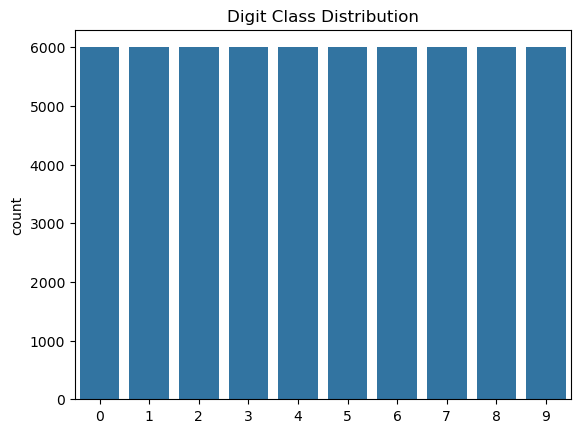

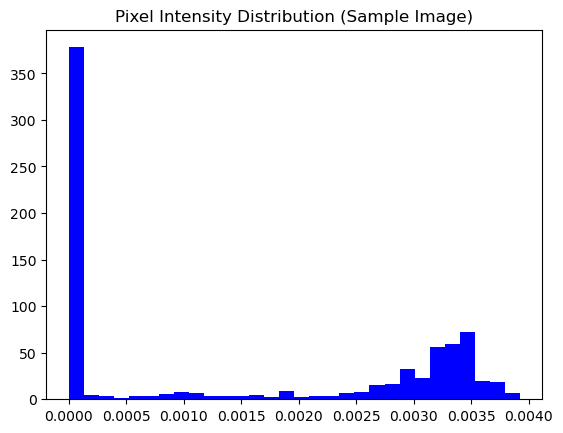

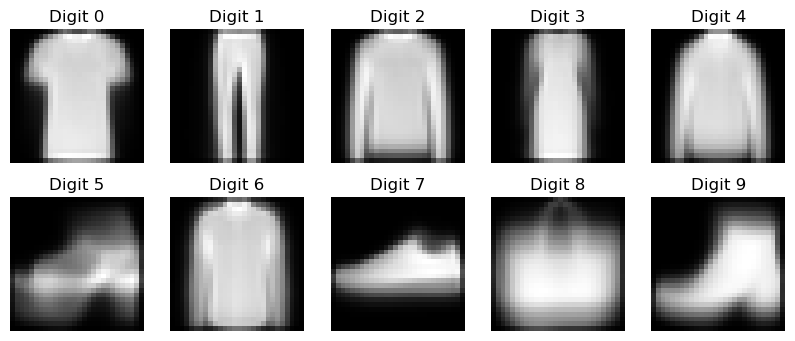

{(28, 28)}
Height range: 28 - 28
Width range: 28 - 28


<Axes: ylabel='Count'>

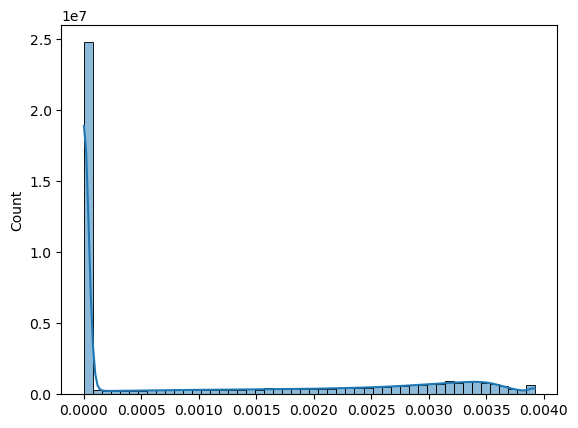

In [50]:
# EDA Workflow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Class Distribution
sns.countplot(x=train_labels)
plt.title("Digit Class Distribution")
plt.show()

# Pixel (Color Distribution) intensity histogram
plt.hist(train_images[0].ravel(), bins=30, color='blue')
plt.title("Pixel Intensity Distribution (Sample Image)")
plt.show()

# Mean image per digit
mean_images = [np.mean(train_images[train_labels==i], axis=0) for i in range(10)]
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(mean_images[i], cmap="gray")
    plt.title(f"Digit {i}")
    plt.axis("off")
plt.show()

# Dimension Verification
dims = [img.shape for img in train_images]
print(set(dims))  # should ideally be one unique dimension

# Identify Anomalies ( Image Dimension Analysis)
heights = [img.shape[0] for img in train_images]
widths = [img.shape[1] for img in train_images]
print("Height range:", min(heights), "-", max(heights))
print("Width range:", min(widths), "-", max(widths))

# Pixel Intensity Distribution
all_pixels = np.concatenate([img.ravel() for img in train_images])
sns.histplot(all_pixels, bins=50, kde=True)

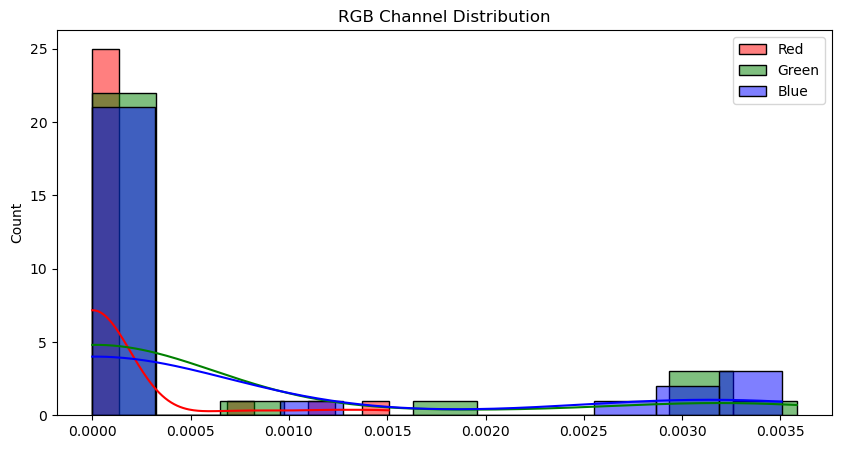

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming train_images[0] is RGB
r = train_images[0][:,0].ravel()
g = train_images[0][:,1].ravel()
b = train_images[0][:,2].ravel()

plt.figure(figsize=(10,5))
sns.histplot(r, color="red", label="Red", kde=True)
sns.histplot(g, color="green", label="Green", kde=True)
sns.histplot(b, color="blue", label="Blue", kde=True)
plt.legend()
plt.title("RGB Channel Distribution")
plt.show()

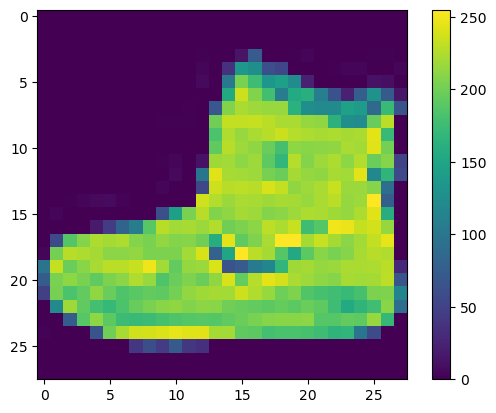

In [12]:
# Using matplotlib 
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

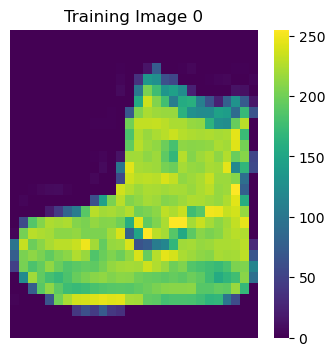

In [13]:
# Using seaborn library
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the first training image using seaborn
plt.figure(figsize=(4,4))
sns.heatmap(train_images[0], 
            cmap="viridis",   # color scheme
            cbar=True,        # adds colorbar
            xticklabels=False, 
            yticklabels=False)

plt.title("Training Image 0")
plt.show()

In [14]:
# Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. 
# It's important that the training set and the testing set be preprocessed in the same way:
# A data preprocessing technique that transforms the numerical features of a dataset to a similar range. 
# This is done to ensure that no single feature dominates the learning process due to differences in their scales, 
# leading to improved model performance and faster convergence.

# Scaling is used to optimize the training process to handle large datasets and complex models efficiently to improve model stability and performance

# If you relate it to Tabular Data - We used Z score to normalize and standardize the data to get accurate result - 
# Especially in KNN and KMeans which are distance based algorithms

In [15]:
train_images = train_images / 255.0

test_images = test_images / 255.0

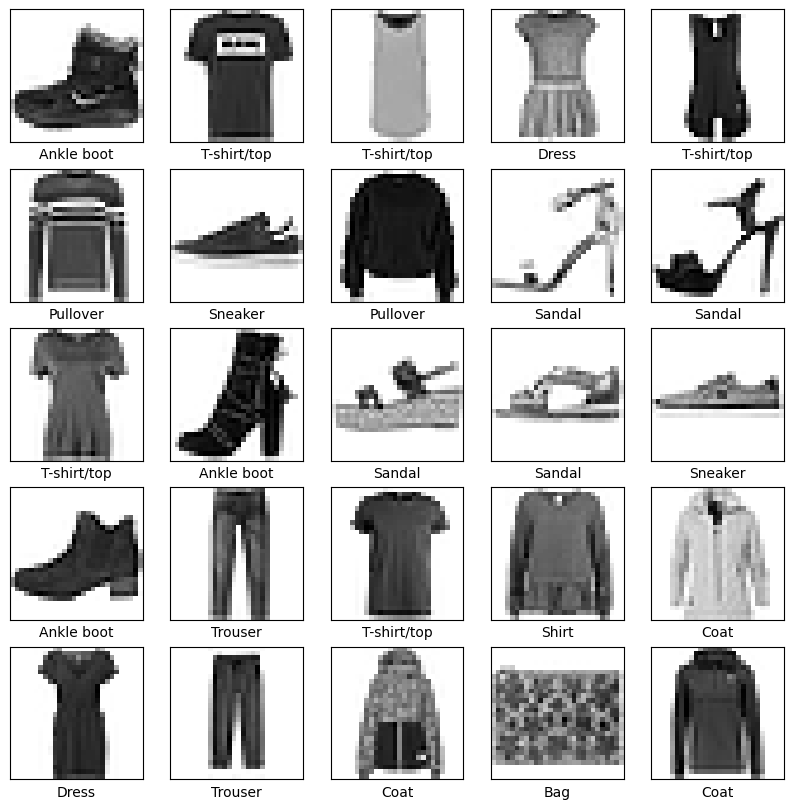

In [16]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

#__________________Prtining the random 5 Images ____________________________________________

# train_images = train_images / 255.0
# test_images = test_images / 255.0
# indexes = np.random.randint(0, train_images.shape[0], size=5)
# images = train_images[indexes]
# labels = train_labels[indexes]
# # plot the 5 images
# for i in range(len(indexes)):
#     # plt.figure(tf.size(images))
#     plt.subplot(2,3, i + 1)
#     image = images[i]
#     plt.imshow(image)
#     plt.colorbar()
#     plt.grid(False)
#     plt.title(f"Label: {labels[i]}")
# plt.show()

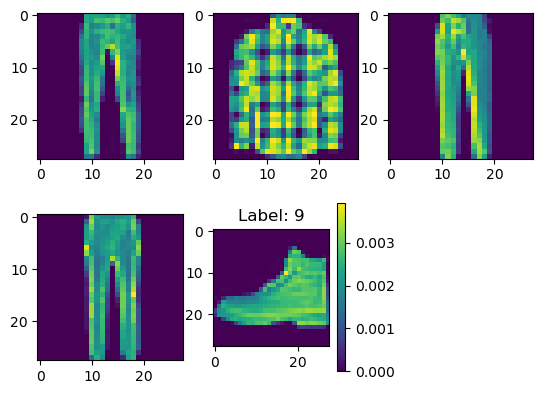

In [17]:
#__________________Prtining the random 5 Images ____________________________________________

train_images = train_images / 255.0
test_images = test_images / 255.0
indexes = np.random.randint(0, train_images.shape[0], size=5)
images = train_images[indexes]
labels = train_labels[indexes]
# # plot the 5 images
for i in range(len(indexes)):
  plt.figure(tf.size(images))
  plt.subplot(2,3, i + 1)
  image = images[i]
  plt.imshow(image)
plt.colorbar()
plt.grid(False)
plt.title(f"Label: {labels[i]}")
plt.show()

# BUILD THE MODEL 
# Building the neural network requires

# a) configuring the layers of the model,
# b) then compiling the model and
# c) training the model with the data (train data)

In [18]:
# a) Set up the layers
# The basic building block of a neural network is the layer. Layers extract representations from the data fed into them. 
# Hopefully, these representations are meaningful for the problem at hand.

# Most of deep learning consists of chaining together simple layers. Most layers, such as tf.keras.layers.
# Dense, have parameters that are learned during training.

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])
# ___________________________________________________
# Homework - What/ Why/ How?
#______________________________________________________


# first layer :  "tf.keras.layers.Flatten(input_shape=(28, 28))"
#___________________________Explanation_______________________________________________

# 1. Sequential -- is for creating a stack of neural network layers
#  Next is for how we want various layers to be built

# 2. layers.Flatten -- is for converting/reshaping a multidimensional array into a 1D vector
#    2.1 -- done for giving as input to the next dense layer
         #(fully connected layer- from each neuron to all the nodes in next layer)
           # which accepts a flattened 1D input
#    2.2 -- Simplifies data handling and model complexity

# flatten will transform the images from a two-dimensional array(28*28 pixels)
# into a one-dimensional array (28*28=784 pixels).
# basically what it does is transform a multi-dimensional tensor
# into a one-dimensional tensor (vector). It does this by preserving the batch size
# and combining all other dimensions

#_____________________________________________________________________________________
# Second Layer: tf.keras.layers.Dense(128, activation='relu'),

# _______________ Explanations _____________________________

# Dense function creates a densely connected layer in which each neuron in the layer
# is connected to EVERY neuron in the previous layer.

# 128 is the number of neurons in the dense layer.
# (This could be any number but the more neurons means it become more intensive)
# bit wise its a 2 raise to the power 7 which makes it easy for computations


# activation = ReLU

# refers the activation function used by neurons in the layer.
# ReLU introduce non-linearity by allowing the neuron to output the input directly
# if it is positive by using the function

# In second layer we are taking a dense layer with 128 nodes
# where each node is connected to every node of input layer.
# Relu is basically used in tensorflow which returns 0 for every negative value
# from input and non-zero otherwise.
# Activation is basically used for deciding weights.

# What is Dense layer?
# Dense Layer is a simple layer of neurons in
# which each neuron receives input from all the neurons of the previous layer


# f(x) = Max(x, 0)

#__________________________________________________________________________________________

# Third Layer:  tf.keras.layers.Dense(10)

# __________________ Explanation __________________________________________________________

# tf.keras.layers.Dense accepts an input "units" and rest all have default values.
# If only "units" then this signifies output layer.
# units-  Positive integer, dimensionality of the output space.
# Why are we doing this?
# The output needs to be classified into one of the 10 classes so, only "10" is passed here.
# How are we doing this?
# output arrays is of shape (None, 10). so only the name of concerned class (which the model has classified) is returned.

C:\Users\tanma\anaconda3\envs\jupyter_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The first layer in this network, tf.keras.layers.Flatten, transforms the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one-dimensional array (of 28 * 28 = 784 pixels). Think of this layer as unstacking rows of pixels in the image and lining them up. This layer has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two tf.keras.layers.Dense layers. These are densely connected, or fully connected, neural layers. The first Dense layer has 128 nodes (or neurons). The second (and last) layer returns a logits array with length of 10. Each node contains a score that indicates the current image belongs to one of the 10 classes.

Compile the model
Before the model is ready for training, it needs a few more settings. These are added during the model's compile step:

Loss function —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.
Optimizer —This is how the model is updated based on the data it sees and its loss function.
Metrics —Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified.

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 1- What is Optimiser and Why adam ?
# ---
# Optimizer is step used to minimize Loss from adjusting Input with Weights.
# Adam optimizer is Combination of Root Mean Square Prop and Momentum
# (Minimum batch gradient descent) optimzers

# Types of optimisers: Gradient Descent,
#     Stochastic Gradient Descent,
#     Mini-batch Gradient Descent,
#     Adagrad, RMS Prop, AdaDelta
#_______________________________________________________________________________
# 2- What is loss function and why Crossentropy?
# ---
# The loss function is a method of evaluating how well your algorithm
# is modeling your dataset.
# It is a mathematical function of the parameters of the machine learning algorithm.


# It measures the inconsistency between predicted and actual outcomes,
# guiding the model towards accuracy in the follow-up iteration (epochs)

# Cross-entropy is widely used as a loss function when optimising classification models.
# Two examples that you may encounter include the
# logistic regression algorithm (a linear classification algorithm),
# and artificial neural networks that can be used for classification tasks
#_______________________________________________________________________________
# 3- What is metrics and what are the other options could have been? 
# ---

# We need to evaluate its performance.
# You can use different metrics, such as mean absolute error (MAE),
# root mean squared error (RMSE), or mean absolute percentage error (MAPE),
# to measure how close your predictions are to the actual values.

# Here we used the Accuracy method, which implies measuring the proportion of correctly
# classified instances out of the total instances.

Train the model
Training the neural network model requires the following steps:

Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
The model learns to associate images and labels.
You ask the model to make predictions about a test set—in this example, the test_images array.
Verify that the predictions match the labels from the test_labels array.

# Feed the model
# To start training, call the model.fit method—so called because it "fits" the model to the training data:

In [22]:
# As the model trains, the loss and accuracy metrics are displayed. 
# This model reaches an accuracy of about 0.91 (or 91%) on the training data.
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6549 - loss: 1.1021
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7664 - loss: 0.6494
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7943 - loss: 0.5706
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8139 - loss: 0.5258
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8240 - loss: 0.4967
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8319 - loss: 0.4761
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8377 - loss: 0.4612
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8415 - loss: 0.4485
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8457 - loss: 0.4387
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8484 - loss: 0.4300


# Evaluate accuracy
# Next, compare how the model performs on the test dataset:

In [51]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)
print('\nTest Loss:', test_loss)

313/313 - 0s - 2ms/step - accuracy: 0.8362 - loss: 0.4581

Test accuracy: 0.8361999988555908

Test Loss: 0.4581192433834076


<!-- Test accuracy: 0.8367000222206116
It turns out that the accuracy on the test dataset is a little less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents overfitting. Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. An overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. For more information, see the following:

Demonstrate overfitting
Strategies to prevent overfitting -->

In [24]:
# Test accuracy: 0.8367000222206116
# It turns out that the accuracy on the test dataset is a little less than the accuracy on the training dataset. 
# This gap between training accuracy and test accuracy represents overfitting. 
# Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. 
# An overfitted model "memorises" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. 

# For more information, see the following:

# Demonstrate overfitting (https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#demonstrate_overfitting)
# Strategies to prevent overfitting (https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#strategies_to_prevent_overfitting)

# Make predictions
# With the model trained, you can use it to make predictions about some images. 
# The model's linear outputs, logits. Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.

In [25]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

# Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [26]:
predictions[0]

array([3.3527212e-07, 1.2976053e-08, 5.5944861e-06, 4.6228761e-06,
       8.1600974e-06, 1.4580144e-01, 9.4051584e-06, 3.6352465e-01,
       4.4073649e-03, 4.8623845e-01], dtype=float32)

In [27]:
np.argmax(predictions[0])
# So, the model is most confident that this image is an ankle boot, or class_names[9]. 
# Examining the test label shows that this classification is correct:

np.int64(9)

In [28]:
test_labels[0]

np.uint8(9)

In [29]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)
def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [30]:
# Verify predictions
# With the model trained, you can use it to make predictions about some images.

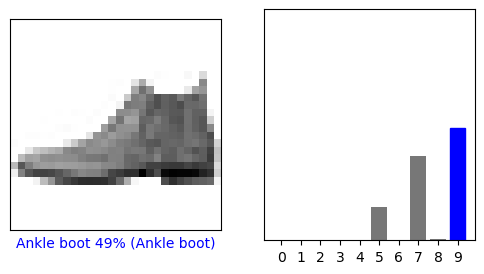

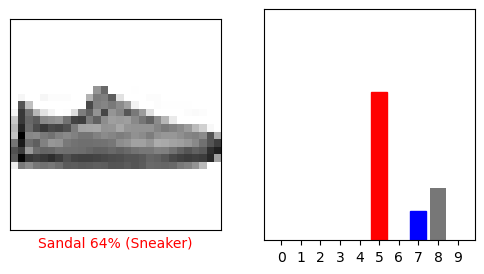

In [31]:
# Verify predictions
# With the model trained, you can use it to make predictions about some images.

# Type Markdown and LaTeX: 

# Let's look at the 0th image, predictions, and prediction array. Correct prediction labels are blue and incorrect prediction labels are red. 
# The number gives the percentage (out of 100) for the predicted label.

i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

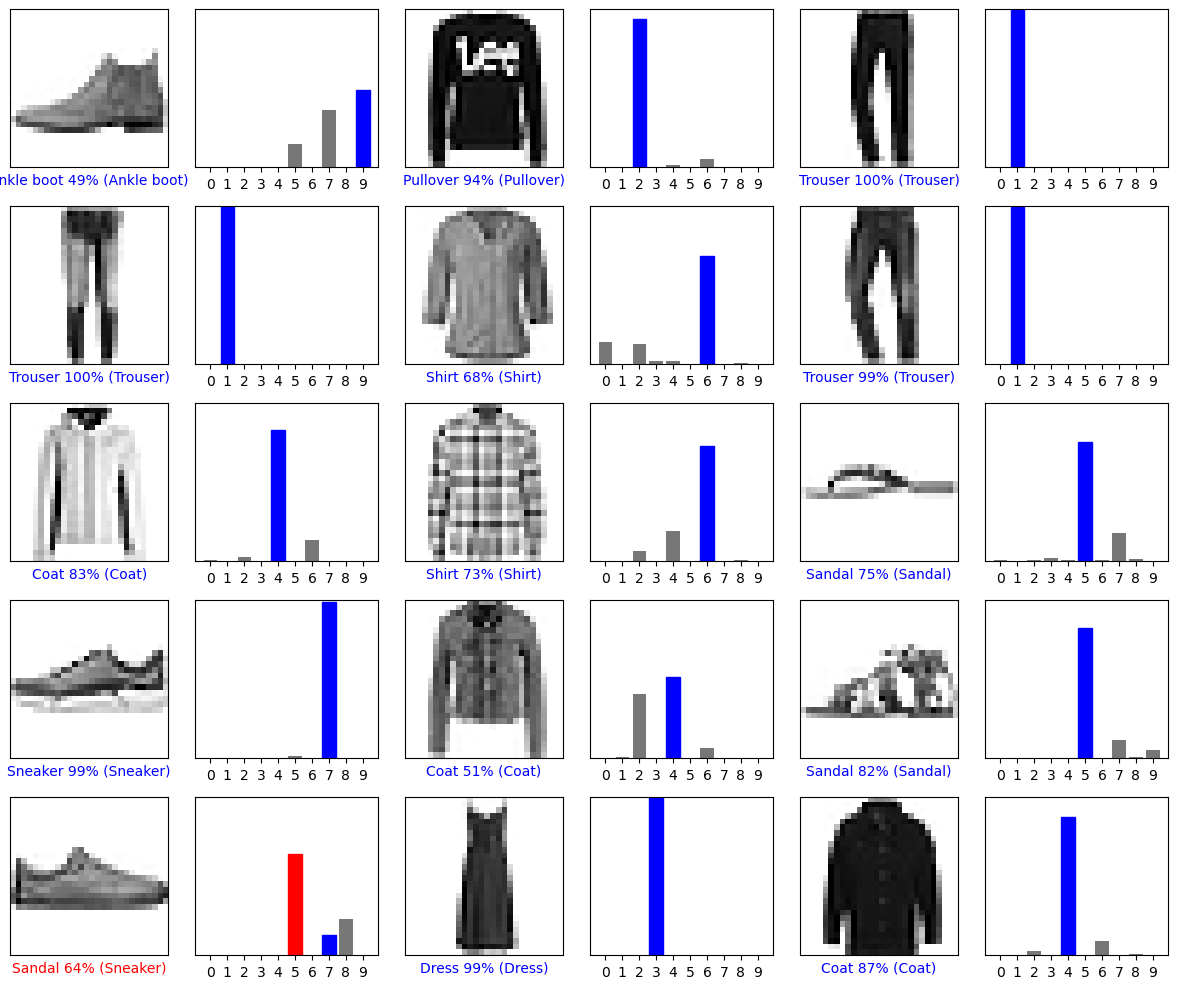

In [32]:
# Let's plot several images with their predictions. Note that the model can be wrong even when very confident.

num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

In [33]:
# Use the trained model
# Finally, use the trained model to make a prediction about a single image.

# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(28, 28)


In [34]:
# tf.keras models are optimized to make predictions on a batch, or collection, of examples at once.
# Accordingly, even though you're using a single image, you need to add it to a list:

# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


In [35]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[2.17401684e-04 1.25895231e-05 9.37878430e-01 1.64251527e-04
  1.22041404e-02 1.26908184e-09 4.94242348e-02 1.05187025e-14
  9.89112887e-05 8.37381813e-12]]


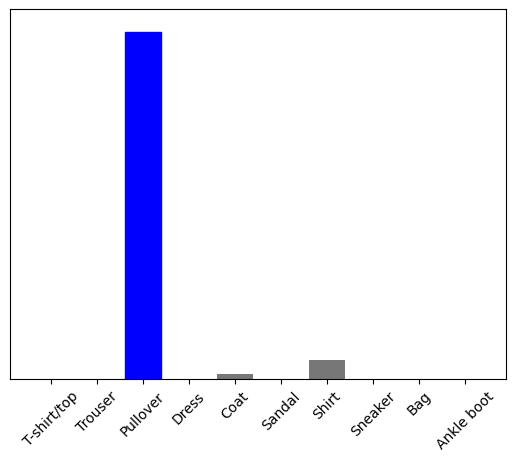

In [36]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)

In [37]:
# tf.keras.Model.predict returns a list of lists—one list for each image in the batch of data. 
# Grab the predictions for our (only) image in the batch:

np.argmax(predictions_single[0])

np.int64(2)